### Overview:

This notebook develops a Random Forest regression model to predict product prices based on product attributes, seller information, review statistics, and category-related features. The workflow includes data preprocessing, feature engineering, train/test/holdout splitting, model training, and evaluation using MAE, RMSE, and R². Additional visualizations are used to analyze prediction behavior on the holdout set and to identify the most influential features learned by the model.

In [34]:
# =========================
# 0. Imports Library
# =========================
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [23]:
# =========================
# 1. Load data
# =========================
df = pd.read_csv("datasets/cleaned_data/products_clean.csv")
print("products_clean.csv shape:", df.shape)

products_clean.csv shape: (12197, 62)


In [24]:
# =========================
# 2. Set target
# =========================
target = "price"

In [25]:
# ==================================================
# I./ CORRELATION MATRIX
# ==================================================

In [26]:
# =========================
# 1. Drop not used columns
# =========================
drop_cols = [
    # leakage
    "original_price", "discount", "discount_rate",

    # ID / technical
    "id", "sku", "seller_product_id", "seller_id",
    "brand_id", "data_version", "source_file",

    # raw / hard to interpret
    "tracking_info_amplitude", "stock_item",
    "badges_new", "badges_v3"
]

df_model = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

In [47]:
# =========================
# 2. Correlation Ratio Function
# =========================
def correlation_ratio(categories, measurements):
    valid = ~(pd.isna(categories) | pd.isna(measurements))
    categories = pd.Series(categories[valid]).astype(str)
    measurements = pd.Series(measurements[valid]).astype(float)

    if len(categories) == 0:
        return np.nan

    grand_mean = measurements.mean()
    grouped = measurements.groupby(categories)

    ss_between = sum(len(group) * (group.mean() - grand_mean) ** 2 for _, group in grouped)
    ss_total = ((measurements - grand_mean) ** 2).sum()

    if ss_total == 0:
        return np.nan

    return np.sqrt(ss_between / ss_total)

In [48]:
# =========================
# 3. Transform bool -> int
# =========================
bool_cols = df_model.select_dtypes(include="bool").columns.tolist()
for col in bool_cols:
    df_model[col] = df_model[col].astype(int)

In [49]:
# =========================
# 4. Column Classification
# =========================
feature_cols = [c for c in df_model.columns if c != target]

numeric_cols = df_model[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in feature_cols if c not in numeric_cols]

In [50]:
# =========================
# 5. Numeric/Binary vs Price: Spearman
# =========================
numeric_results = []

for col in numeric_cols:
    tmp = df_model[[col, target]].dropna()
    if tmp[col].nunique() <= 1:
        corr_val = np.nan
    else:
        corr_val = tmp[col].corr(tmp[target], method="spearman")

    numeric_results.append({
        "feature": col,
        "feature_type": "numeric_or_binary",
        "association_method": "spearman",
        "association_value": corr_val,
        "abs_association": np.abs(corr_val) if pd.notna(corr_val) else np.nan,
        "n_unique": df_model[col].nunique()
    })

numeric_results = pd.DataFrame(numeric_results)

In [51]:
# =========================
# 6. Categorical vs Price: Eta
# =========================
categorical_results = []

for col in categorical_cols:
    tmp = df_model[[col, target]].dropna()
    if tmp[col].nunique() <= 1:
        eta_val = np.nan
    else:
        eta_val = correlation_ratio(tmp[col], tmp[target])

    categorical_results.append({
        "feature": col,
        "feature_type": "categorical",
        "association_method": "eta",
        "association_value": eta_val,
        "abs_association": eta_val,   # eta always >= 0
        "n_unique": df_model[col].nunique()
    })

categorical_results = pd.DataFrame(categorical_results)

In [52]:
# =========================
# 7. Merge, Sort, Select
# =========================
association_table = pd.concat([numeric_results, categorical_results], ignore_index=True)
association_table = association_table.sort_values("abs_association", ascending=False)

# print("=== Association of all features with price ===")
# print(association_table)

selected_features = association_table[
    association_table["abs_association"] >= 0.05
]["feature"].tolist()

# print("Selected features:", selected_features)
# print("Number of selected features:", len(selected_features))

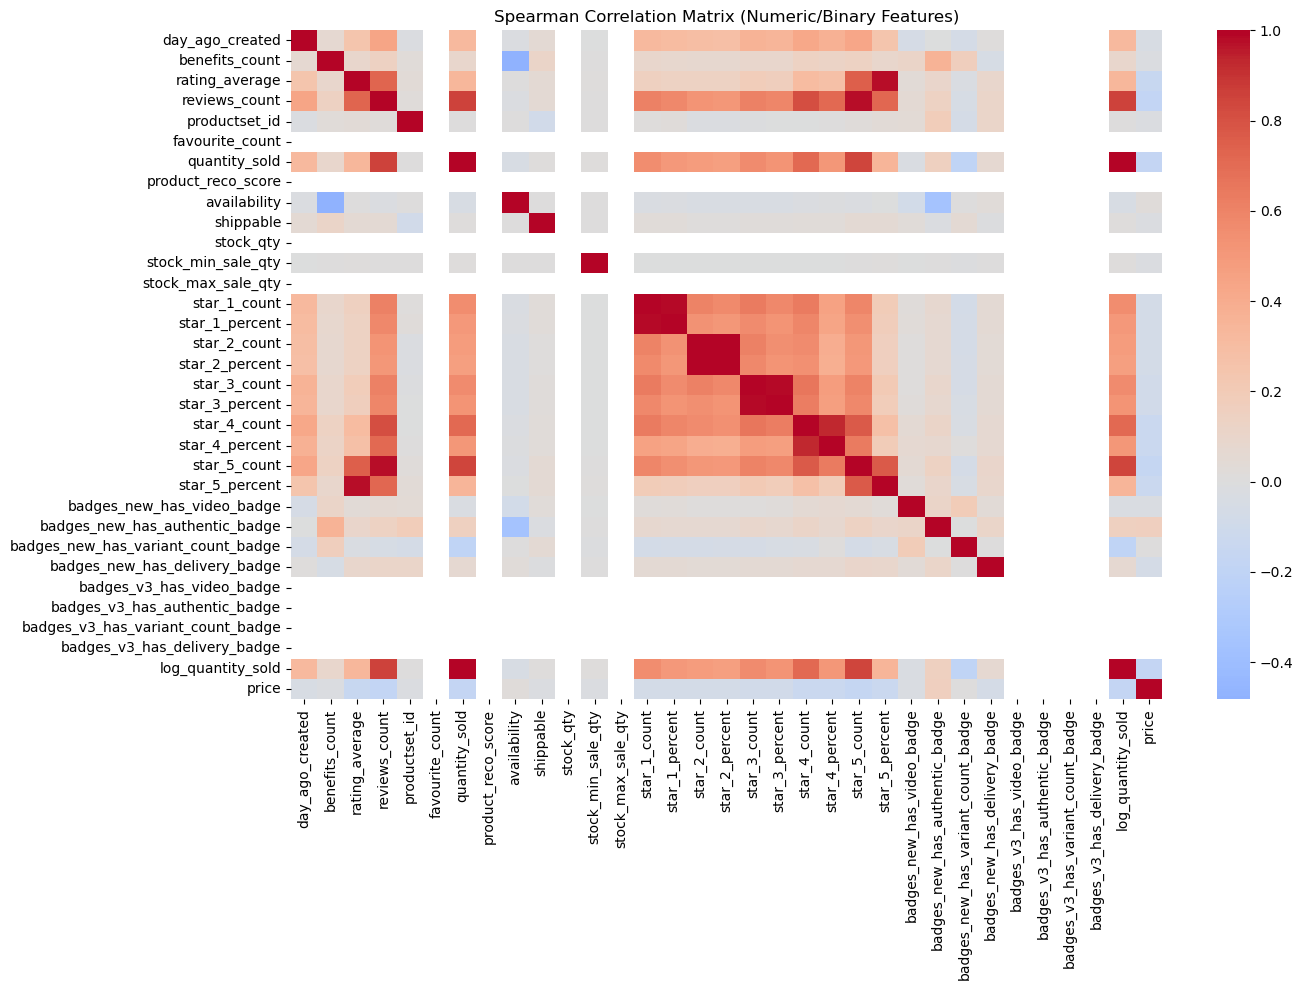

In [35]:
# =========================
# 8. Visualization
# =========================

numeric_for_corr = [c for c in numeric_cols if c != target] + [target]

corr_matrix = df_model[numeric_for_corr].corr(method="spearman")

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Spearman Correlation Matrix (Numeric/Binary Features)")
plt.tight_layout()
plt.show()

In [19]:
# ==================================================
# II./ RANDOM FOREST MODEL
# ==================================================

In [36]:
# =========================
# 1. Feature engineering from name
# =========================
def extract_storage_gb(text):
    if pd.isna(text):
        return np.nan
    text = str(text).lower().replace(",", ".")

    tb_match = re.search(r'(\d+(?:\.\d+)?)\s*tb', text)
    if tb_match:
        return float(tb_match.group(1)) * 1024

    gb_match = re.search(r'(\d+(?:\.\d+)?)\s*gb', text)
    if gb_match:
        return float(gb_match.group(1))

    return np.nan

def extract_ram_gb(text):
    if pd.isna(text):
        return np.nan
    text = str(text).lower().replace(",", ".")

    ram_match = re.search(r'ram\s*(\d+(?:\.\d+)?)\s*gb', text)
    if ram_match:
        return float(ram_match.group(1))

    return np.nan

def extract_inch(text):
    if pd.isna(text):
        return np.nan
    text = str(text).lower().replace(",", ".")

    inch_match = re.search(r'(\d+(?:\.\d+)?)\s*(?:inch|inches|")', text)
    if inch_match:
        return float(inch_match.group(1))

    return np.nan

def has_keyword(text, keyword):
    if pd.isna(text):
        return 0
    return int(keyword.lower() in str(text).lower())

if "name" in df.columns:
    df["name_storage_gb"] = df["name"].apply(extract_storage_gb)
    df["name_ram_gb"] = df["name"].apply(extract_ram_gb)
    df["name_inch"] = df["name"].apply(extract_inch)

    df["name_has_pro"] = df["name"].apply(lambda x: has_keyword(x, "pro"))
    df["name_has_plus"] = df["name"].apply(lambda x: has_keyword(x, "plus"))
    df["name_has_ultra"] = df["name"].apply(lambda x: has_keyword(x, "ultra"))
    df["name_has_max"] = df["name"].apply(lambda x: has_keyword(x, "max"))
    df["name_has_combo"] = df["name"].apply(lambda x: has_keyword(x, "combo"))
    df["name_has_set"] = df["name"].apply(lambda x: has_keyword(x, "set"))
    df["name_has_pack"] = df["name"].apply(lambda x: has_keyword(x, "pack"))

# print("\n=== Preview engineered name features ===")
name_feature_cols = [
    c for c in [
        "name_storage_gb", "name_ram_gb", "name_inch",
        "name_has_pro", "name_has_plus", "name_has_ultra",
        "name_has_max", "name_has_combo", "name_has_set", "name_has_pack"
    ] if c in df.columns
]
# print(df[name_feature_cols].head())

In [37]:
# =========================
# 2. Define features
# =========================
# target = "price"

base_features = [
    "primary_category_path",
    "brand_or_author",
    "brand_name",
    "categories",
    "category",
    "reviews_count",
    "log_quantity_sold",
    "badges_new_has_authentic_badge",
    "rating_average",
    "star_5_percent",
    "star_4_percent",
    "star_3_percent",
    "star_2_percent",
    "star_1_percent",
    "badges_new_has_delivery_badge",
    "is_top_brand"
]

high_cardinality_features = base_features + [
    "name",
    "current_seller"
]

engineered_name_features = [
    c for c in [
        "name_storage_gb", "name_ram_gb", "name_inch",
        "name_has_pro", "name_has_plus", "name_has_ultra",
        "name_has_max", "name_has_combo", "name_has_set", "name_has_pack"
    ] if c in df.columns
]

features_improved = high_cardinality_features + engineered_name_features
features_improved = [c for c in features_improved if c in df.columns]

print("\nNumber of features:", len(features_improved))
print(features_improved)


Number of features: 28
['primary_category_path', 'brand_or_author', 'brand_name', 'categories', 'category', 'reviews_count', 'log_quantity_sold', 'badges_new_has_authentic_badge', 'rating_average', 'star_5_percent', 'star_4_percent', 'star_3_percent', 'star_2_percent', 'star_1_percent', 'badges_new_has_delivery_badge', 'is_top_brand', 'name', 'current_seller', 'name_storage_gb', 'name_ram_gb', 'name_inch', 'name_has_pro', 'name_has_plus', 'name_has_ultra', 'name_has_max', 'name_has_combo', 'name_has_set', 'name_has_pack']


In [38]:
# =========================
# 3. Prepare data
# =========================
data = df[features_improved + [target]].copy()
data = data.dropna(subset=[target]).reset_index(drop=True)
data = data[data[target] >= 0].reset_index(drop=True)

# target = log(price)
data["log_price"] = np.log1p(data[target])

In [46]:
# =========================
# 4. Split data: 70/30
# =========================
dev_data, holdout_data = train_test_split(
    data,
    test_size=0.30,
    random_state=42
)

train_data, test_data = train_test_split(
    dev_data,
    test_size=0.20,
    random_state=42
)

X_train = train_data[features_improved].copy()
y_train_log = train_data["log_price"].copy()

X_test = test_data[features_improved].copy()
y_test_log = test_data["log_price"].copy()

X_holdout = holdout_data[features_improved].copy()
y_holdout_log = holdout_data["log_price"].copy()

# giá thật để đánh giá
y_test_actual = test_data[target].copy()
y_holdout_actual = holdout_data[target].copy()

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Holdout shape:", X_holdout.shape)


Train shape: (6829, 28)
Test shape: (1708, 28)
Holdout shape: (3660, 28)


In [40]:
# =========================
# 5. Detect categorical and numeric columns
# =========================
categorical_cols = [
    col for col in X_train.columns
    if X_train[col].dtype == "object"
    or str(X_train[col].dtype) == "category"
    or str(X_train[col].dtype) == "bool"
]

numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

print("\nCategorical columns:", categorical_cols)
print("\nNumeric columns:", numeric_cols)


Categorical columns: ['primary_category_path', 'brand_or_author', 'brand_name', 'categories', 'category', 'badges_new_has_authentic_badge', 'badges_new_has_delivery_badge', 'is_top_brand', 'name', 'current_seller']

Numeric columns: ['reviews_count', 'log_quantity_sold', 'rating_average', 'star_5_percent', 'star_4_percent', 'star_3_percent', 'star_2_percent', 'star_1_percent', 'name_storage_gb', 'name_ram_gb', 'name_inch', 'name_has_pro', 'name_has_plus', 'name_has_ultra', 'name_has_max', 'name_has_combo', 'name_has_set', 'name_has_pack']


In [63]:
# =========================
# 6. Preprocessing
# =========================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [62]:
# =========================
# 7. Build Random Forest pipeline
# =========================
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

In [60]:
# =========================
# 8. Train Random Forest on log(price)
# =========================
rf_pipeline.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [61]:
# =========================
# 9. Evaluate on test
# =========================
y_test_pred_log_rf = rf_pipeline.predict(X_test)
y_test_pred_price_rf = np.expm1(y_test_pred_log_rf)

mae_test_rf = mean_absolute_error(y_test_actual, y_test_pred_price_rf)
rmse_test_rf = np.sqrt(mean_squared_error(y_test_actual, y_test_pred_price_rf))
r2_test_rf = r2_score(y_test_actual, y_test_pred_price_rf)

print("\n=== Random Forest: Test Evaluation ===")
print("MAE :", mae_test_rf)
print("RMSE:", rmse_test_rf)
print("R2  :", r2_test_rf)


=== Random Forest: Test Evaluation ===
MAE : 789346.7566766465
RMSE: 3990666.126473841
R2  : 0.644386004037278


In [59]:
# =========================
# 10. Evaluate on holdout
# =========================
y_holdout_pred_log_rf = rf_pipeline.predict(X_holdout)
y_holdout_pred_price_rf = np.expm1(y_holdout_pred_log_rf)

mae_holdout_rf = mean_absolute_error(y_holdout_actual, y_holdout_pred_price_rf)
rmse_holdout_rf = np.sqrt(mean_squared_error(y_holdout_actual, y_holdout_pred_price_rf))
r2_holdout_rf = r2_score(y_holdout_actual, y_holdout_pred_price_rf)

print("\n=== Random Forest: Holdout Evaluation ===")
print("MAE :", mae_holdout_rf)
print("RMSE:", rmse_holdout_rf)
print("R2  :", r2_holdout_rf)


=== Random Forest: Holdout Evaluation ===
MAE : 587231.0796593191
RMSE: 3307946.62156748
R2  : 0.680280656508


In [58]:
# =========================
# 11. Prediction analysis on HOLDOUT dataset
# =========================

# create dataframe analyzed from holdout features
holdout_rf = X_holdout.copy()

# actual price
holdout_rf["actual_price"] = y_holdout_actual.values

# predicted price
holdout_rf["predicted_price"] = y_holdout_pred_price_rf

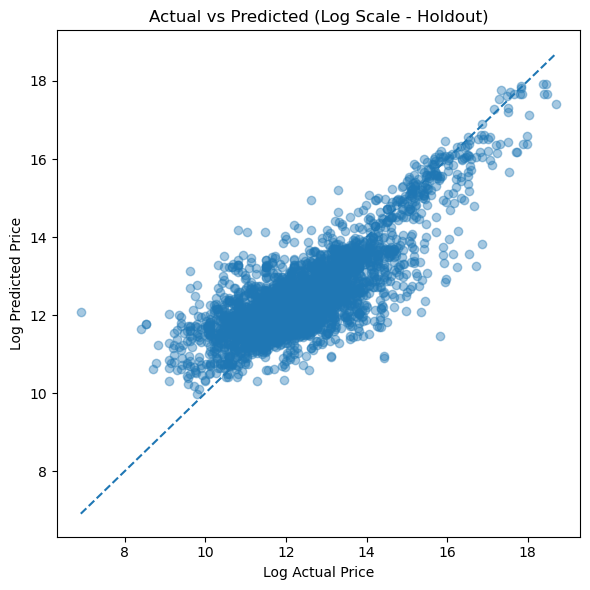

In [57]:
# =========================
# 12. Visualization: Actual vs Predicted (Holdout)
# =========================
plt.figure(figsize=(6,6))

x_log = np.log1p(holdout_rf["actual_price"])
y_log = np.log1p(holdout_rf["predicted_price"])

plt.scatter(x_log, y_log, alpha=0.4)

min_val = min(x_log.min(), y_log.min())
max_val = max(x_log.max(), y_log.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Log Actual Price")
plt.ylabel("Log Predicted Price")
plt.title("Actual vs Predicted (Log Scale - Holdout)")

plt.tight_layout()
plt.show()

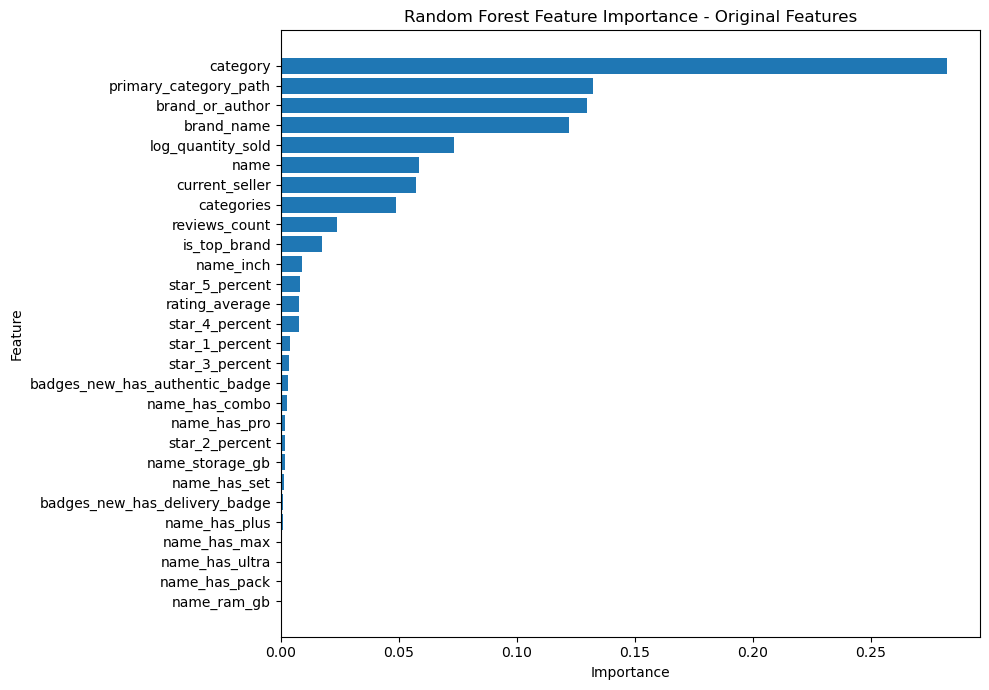

In [56]:
# =========================
# 13. Feature Importance - Original Features
# =========================

# lấy preprocessor và model từ pipeline
preprocessor = rf_pipeline.named_steps["preprocessor"]
rf_model = rf_pipeline.named_steps["model"]

# lấy tên feature sau preprocessing
try:
    transformed_feature_names = preprocessor.get_feature_names_out()
except:
    transformed_feature_names = [f"feature_{i}" for i in range(len(rf_model.feature_importances_))]

# tạo bảng importance ở mức transformed features
importance_df = pd.DataFrame({
    "transformed_feature": transformed_feature_names,
    "importance": rf_model.feature_importances_
})

# dùng đúng danh sách feature gốc đã train
original_features = features_improved.copy()

def map_to_original_feature(transformed_name):
    """
    Map transformed feature back to original feature name.
    Works for:
    - num__feature
    - cat__feature_value
    """
    for feat in original_features:
        if transformed_name == f"num__{feat}":
            return feat
        if transformed_name == f"cat__{feat}":
            return feat
        if transformed_name.startswith(f"cat__{feat}_"):
            return feat
    return transformed_name

importance_df["original_feature"] = importance_df["transformed_feature"].apply(map_to_original_feature)

# gộp importance theo feature gốc
grouped_importance_df = (
    importance_df
    .groupby("original_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

# print("Feature importance grouped by original features:")
# print(grouped_importance_df)

# vẽ biểu đồ giống style bạn muốn
plt.figure(figsize=(10, 7))
plt.barh(
    grouped_importance_df["original_feature"][::-1],
    grouped_importance_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance - Original Features")
plt.tight_layout()
plt.show()